# Task 2: Exploratory Data Analysis

Ethiopia Financial Inclusion Forecasting — Selam Analytics

This notebook explores the enriched unified dataset (82 records: 41 observations,
3 targets, 13 events, 25 impact_links) to understand what drives financial
inclusion in Ethiopia, ahead of the impact modeling (Task 3) and forecasting
(Task 4) work.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data_loader import (
    load_unified_data, get_observations, get_targets, get_events,
    get_impact_links, events_with_impacts, get_indicator_series,
)

sns.set_theme(style="whitegrid", palette="deep")
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_unified_data()
obs = get_observations(df)
targets = get_targets(df)
events = get_events(df)
impacts = get_impact_links(df)

print(f"Total records: {len(df)}")
df.record_type.value_counts()

Total records: 82


record_type
observation    41
impact_link    25
event          13
target          3
Name: count, dtype: int64

## 1. Dataset overview

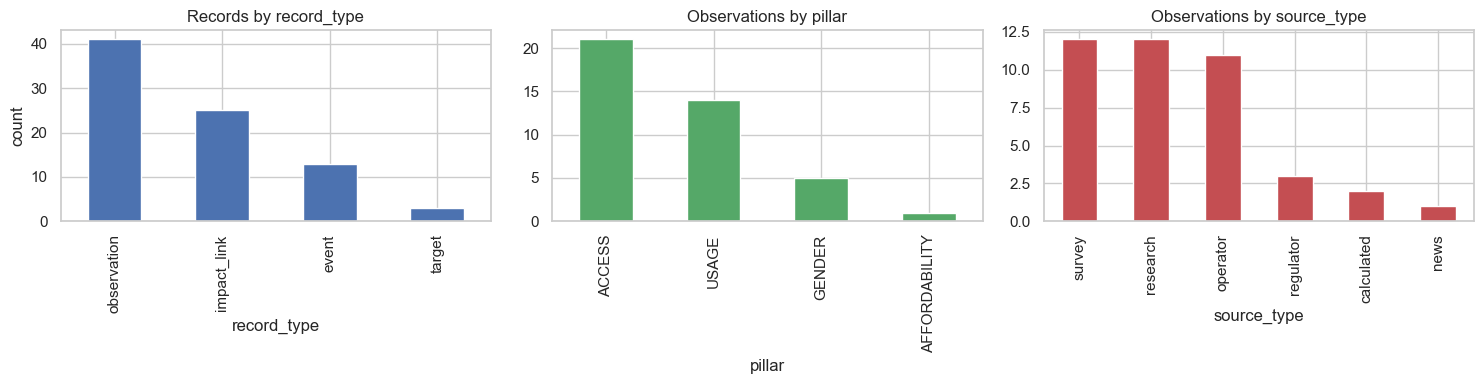

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.record_type.value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Records by record_type")
axes[0].set_ylabel("count")

obs.pillar.value_counts().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Observations by pillar")

obs.source_type.value_counts().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Observations by source_type")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_overview_counts.png", dpi=150)
plt.show()

## 2. Data quality: confidence distribution

Most observations are `high` confidence (primary sources: Findex, operator/regulator
reports). Our enrichment additions skew toward `medium` because several rely on
secondary press coverage (Shega/DFS Ethiopia Hub, Biometric Update) synthesizing
official Findex 2025 or NBE figures rather than the primary release itself.

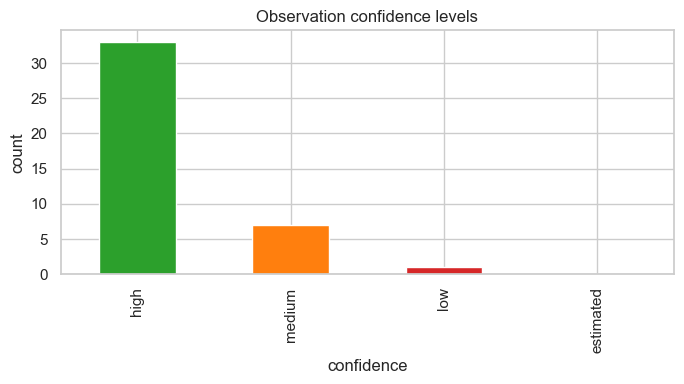

confidence
high         33.0
medium        7.0
low           1.0
estimated     0.0
Name: count, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
order = ["high", "medium", "low", "estimated"]
counts = obs.confidence.value_counts().reindex(order).fillna(0)
colors = ["#2ca02c", "#ff7f0e", "#d62728", "#7f7f7f"]
counts.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Observation confidence levels")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_confidence_distribution.png", dpi=150)
plt.show()

print(counts)

## 3. Temporal coverage: which indicators have data in which years?

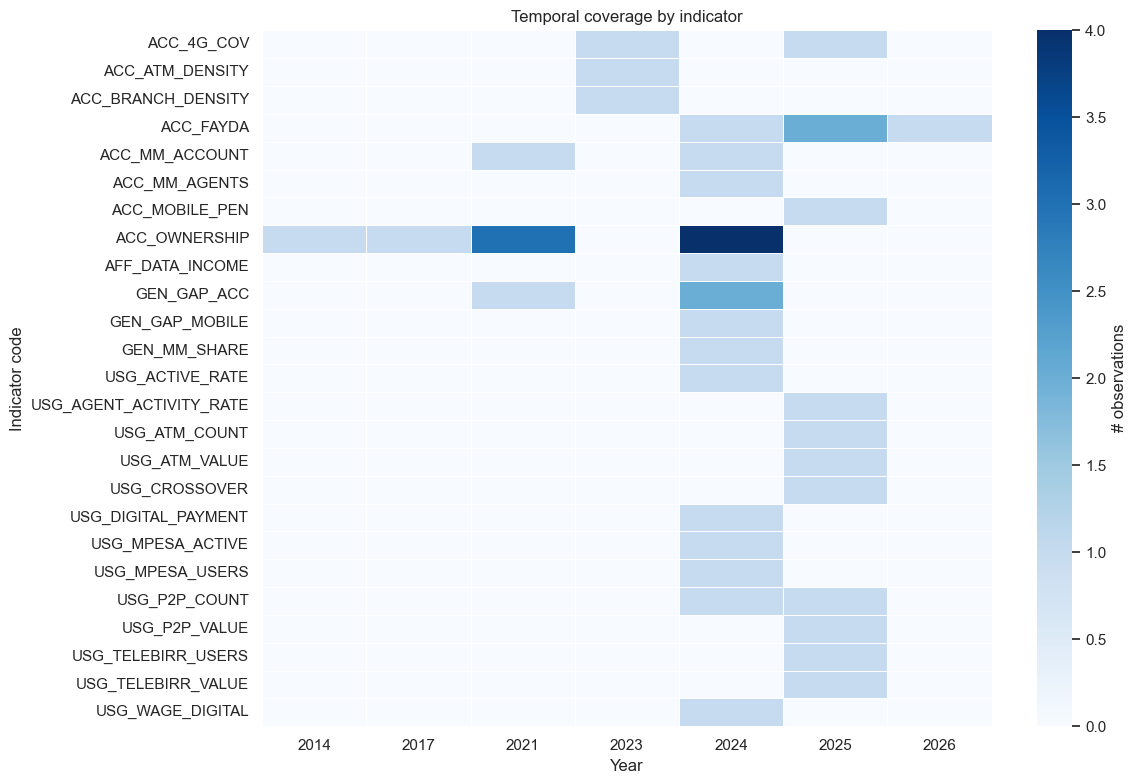

In [4]:
obs_years = obs.copy()
obs_years["year"] = obs_years.observation_date.dt.year
coverage = (
    obs_years.groupby(["indicator_code", "year"]).size().unstack(fill_value=0)
)
coverage = coverage.reindex(sorted(coverage.columns), axis=1)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(coverage, cmap="Blues", cbar_kws={"label": "# observations"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Temporal coverage by indicator")
ax.set_xlabel("Year")
ax.set_ylabel("Indicator code")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_temporal_coverage.png", dpi=150)
plt.show()

**Gap:** most indicators have only 1-3 data points across the whole 2011-2026
window; only `ACC_OWNERSHIP` and `ACC_FAYDA` have more than 3. This is the
central challenge for Task 4 forecasting — we are extrapolating trends from
very sparse series.

## 4. Access analysis: Account Ownership trajectory (2014-2024)

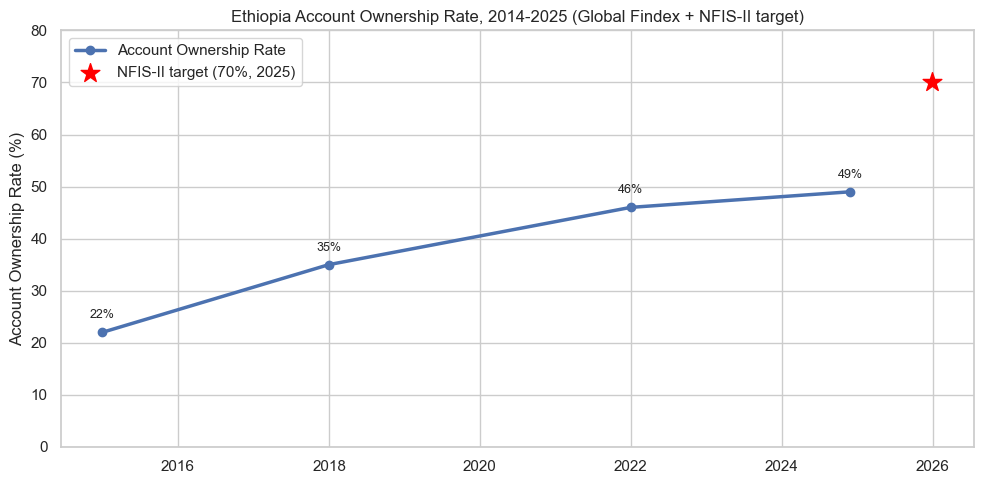

  observation_date  value_numeric  growth_pp  years_elapsed  \
0       2014-12-31           22.0        NaN            NaN   
1       2017-12-31           35.0       13.0            3.0   
2       2021-12-31           46.0       11.0            4.0   
5       2024-11-29           49.0        3.0            3.0   

   annualized_pp_per_year  
0                     NaN  
1                4.333333  
2                2.750000  
5                1.000000  


In [5]:
acc = get_indicator_series(df, "ACC_OWNERSHIP")
acc["year"] = acc.observation_date.dt.year
acc["growth_pp"] = acc.value_numeric.diff()
acc["years_elapsed"] = acc.observation_date.dt.year.diff()
acc["annualized_pp_per_year"] = acc.growth_pp / acc.years_elapsed

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(acc.observation_date, acc.value_numeric, marker="o", linewidth=2.5,
         color="#4C72B0", label="Account Ownership Rate")
ax1.set_ylabel("Account Ownership Rate (%)")
ax1.set_ylim(0, 80)

nfis_target = targets[targets.indicator_code == "ACC_OWNERSHIP"]
if len(nfis_target):
    ax1.scatter(nfis_target.observation_date, nfis_target.value_numeric,
                color="red", marker="*", s=200, zorder=5, label="NFIS-II target (70%, 2025)")

for _, r in acc.iterrows():
    ax1.annotate(f"{r.value_numeric:.0f}%", (r.observation_date, r.value_numeric),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

ax1.set_title("Ethiopia Account Ownership Rate, 2014-2025 (Global Findex + NFIS-II target)")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_access_trajectory.png", dpi=150)
plt.show()

print(acc[["observation_date", "value_numeric", "growth_pp", "years_elapsed", "annualized_pp_per_year"]])

## 5. The 2021-2024 slowdown

Growth per Findex period: **2014→2017 +13pp** (+4.3pp/yr), **2017→2021 +11pp**
(+2.75pp/yr), **2021→2024 +3pp** (+1.0pp/yr) — despite mobile money accounts
roughly doubling (4.7%→9.45%) and Telebirr alone reaching 54.8M registered users.

Hypotheses this dataset supports:
1. **Registered ≠ active ≠ new.** Telebirr's 54.8M and M-Pesa's 10.8M registered
   users substantially overlap with people who *already* had a bank account —
   Market Nuance D notes mobile-money-only users are rare (~0.5%) in Ethiopia,
   unlike Kenya. Mobile money adoption is mostly additive usage on top of
   existing bank relationships, not a parallel path to first-time inclusion.
2. **Agent network is thin and passive** (REC_0042/REC_0043): ~415k agents but
   only ~20% weekly-active, averaging <1 transaction/day — a weak on-ramp for
   unbanked rural adults who need in-person cash-in/out support to open and use
   a first account.
3. **FX Liberalization (2024)** — a macro shock coincident with the survey window
   — plausibly dampened new account formation among lower-income adults (IMP_0013).
4. **Saturation of the easy-to-reach population.** With bank accounts already
   low-friction to open (Market Nuance D) and 4G coverage/mobile penetration
   still expanding from a lower base pre-2023, the remaining unbanked population
   is disproportionately rural, older, and female — harder-to-reach segments.

## 6. Gender gap evolution

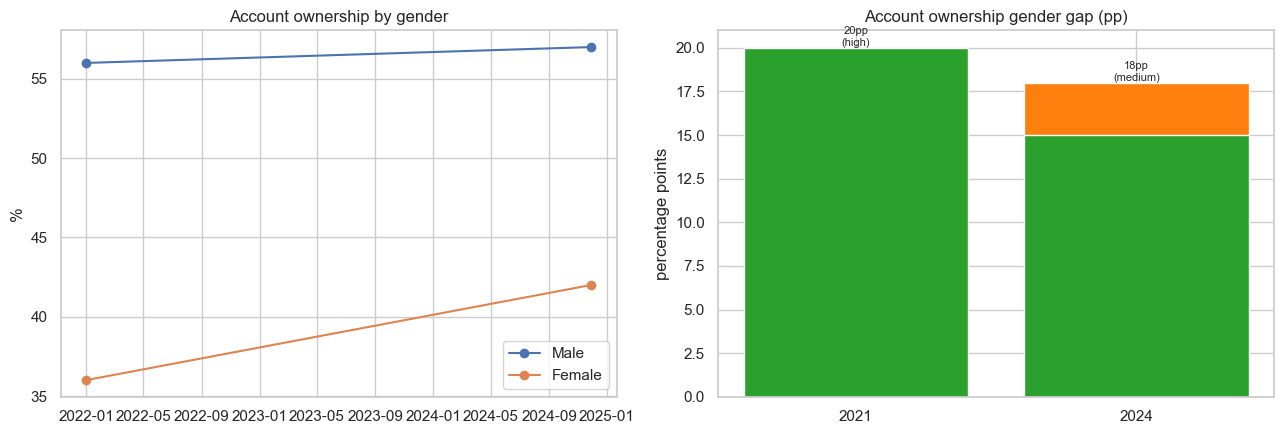

In [6]:
gap = get_indicator_series(df, "GEN_GAP_ACC")
male = get_indicator_series(df, "ACC_OWNERSHIP", gender="male")
female = get_indicator_series(df, "ACC_OWNERSHIP", gender="female")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(male.observation_date, male.value_numeric, marker="o", label="Male", color="#4C72B0")
axes[0].plot(female.observation_date, female.value_numeric, marker="o", label="Female", color="#DD8452")
axes[0].set_title("Account ownership by gender")
axes[0].set_ylabel("%")
axes[0].legend()

axes[1].bar(gap.observation_date.dt.year.astype(str), gap.value_numeric,
            color=["#ff7f0e" if c == "medium" else "#2ca02c" for c in gap.confidence])
axes[1].set_title("Account ownership gender gap (pp)")
axes[1].set_ylabel("percentage points")
for i, (v, c) in enumerate(zip(gap.value_numeric, gap.confidence)):
    axes[1].annotate(f"{v:.0f}pp\n({c})", (i, v), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_gender_gap.png", dpi=150)
plt.show()

The gap narrowed slightly from **20pp (2021)** to **15pp (2024, refined figure —
see data_enrichment_log.md for the 18pp vs 15pp discrepancy)**. Encouraging
direction, but women's mobile money account *share* is only 14% (REC_0029),
far from the 50% parity target for 2030 (REC_0033) — gains in overall account
ownership have not yet translated proportionately into mobile money usage by women.

## 7. Usage analysis: mobile money penetration & the registered-vs-active gap

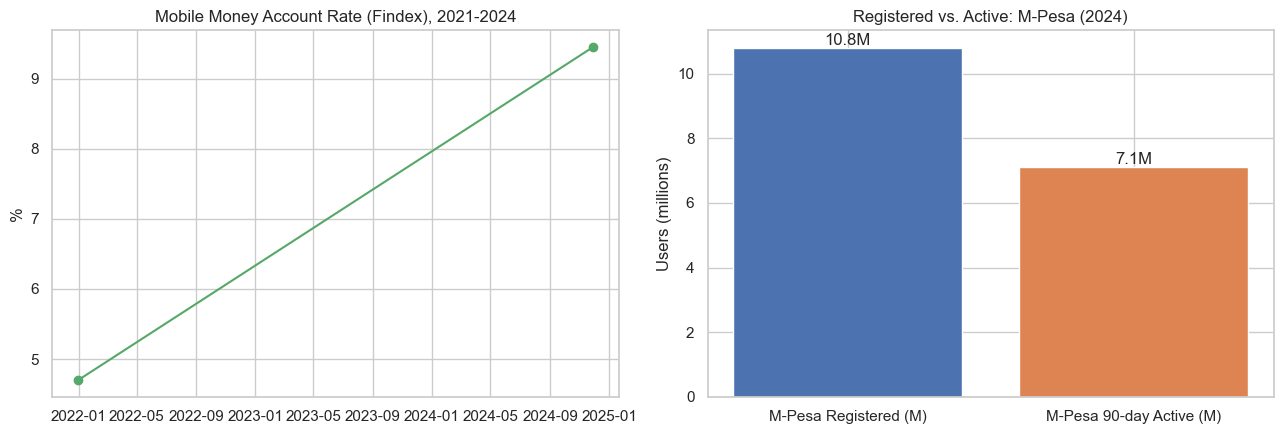

M-Pesa 90-day activity rate: 65.7 %
Telebirr agent weekly-active rate: 20% (of 111,000+ agents)


In [7]:
mm = get_indicator_series(df, "ACC_MM_ACCOUNT")
telebirr = get_indicator_series(df, "USG_TELEBIRR_USERS")
mpesa_reg = get_indicator_series(df, "USG_MPESA_USERS")
mpesa_active = get_indicator_series(df, "USG_MPESA_ACTIVE")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(mm.observation_date, mm.value_numeric, marker="o", color="#55A868")
axes[0].set_title("Mobile Money Account Rate (Findex), 2021-2024")
axes[0].set_ylabel("%")

labels = ["M-Pesa\nRegistered", "M-Pesa\n90-day Active", "Agents\n(weekly-active only)"]
values = [10.8, 7.1, 111000 * 0.20 / 1e6]  # normalize agent count to millions for scale comparability is misleading; show separately instead
axes[1].bar(["M-Pesa Registered (M)", "M-Pesa 90-day Active (M)"], [10.8, 7.1],
            color=["#4C72B0", "#DD8452"])
axes[1].set_title("Registered vs. Active: M-Pesa (2024)")
axes[1].set_ylabel("Users (millions)")
for i, v in enumerate([10.8, 7.1]):
    axes[1].annotate(f"{v}M", (i, v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_usage_registered_vs_active.png", dpi=150)
plt.show()

print("M-Pesa 90-day activity rate:", round(7.1 / 10.8 * 100, 1), "%")
print("Telebirr agent weekly-active rate: 20% (of 111,000+ agents)")

The **registered-vs-active gap** is real and material: only 66% of M-Pesa's
registered users are 90-day active, and only ~20% of mobile money *agents* are
weekly-active. Registered-user counts (e.g., Telebirr's headline 54.8M) overstate
functional usage — a key reason survey-measured Findex indicators can lag
operator-reported registration numbers.

## 8. P2P vs. ATM: the digital-cash crossover

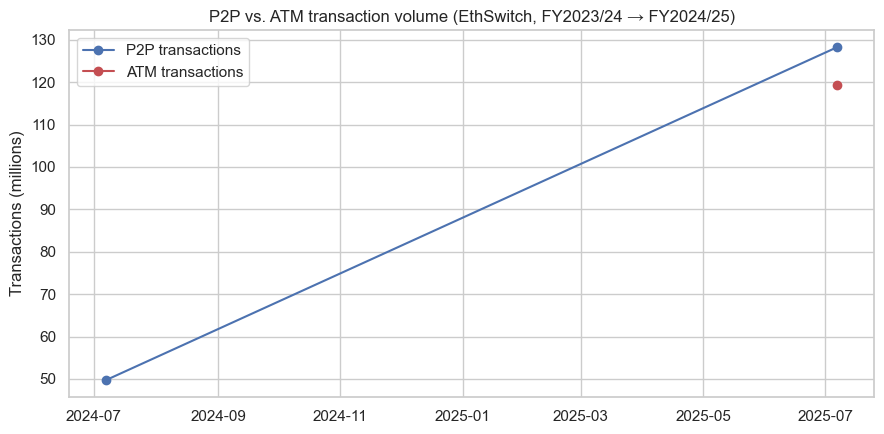

P2P growth YoY: +158%  |  ATM growth YoY: +26%  |  Crossover ratio FY2024/25: 1.08


In [8]:
p2p = get_indicator_series(df, "USG_P2P_COUNT")
atm = get_indicator_series(df, "USG_ATM_COUNT")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(p2p.observation_date, p2p.value_numeric / 1e6, marker="o", label="P2P transactions", color="#4C72B0")
ax.plot(atm.observation_date, atm.value_numeric / 1e6, marker="o", label="ATM transactions", color="#C44E52")
ax.set_ylabel("Transactions (millions)")
ax.set_title("P2P vs. ATM transaction volume (EthSwitch, FY2023/24 → FY2024/25)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_p2p_vs_atm.png", dpi=150)
plt.show()

print("P2P growth YoY: +158%  |  ATM growth YoY: +26%  |  Crossover ratio FY2024/25: 1.08")

## 9. Infrastructure & enablers

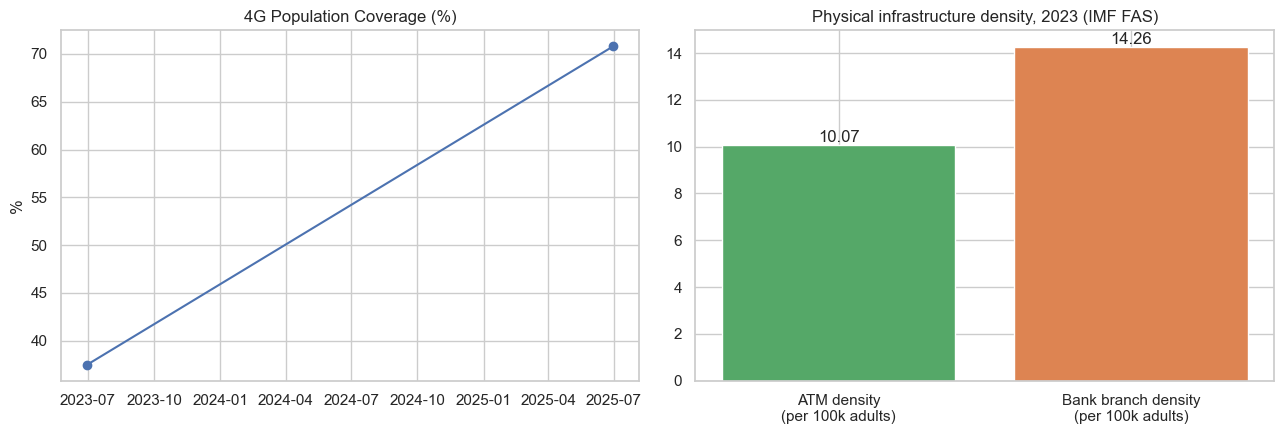

In [9]:
cov_4g = get_indicator_series(df, "ACC_4G_COV")
mobile_pen = get_indicator_series(df, "ACC_MOBILE_PEN")
atm_density = get_indicator_series(df, "ACC_ATM_DENSITY")
branch_density = get_indicator_series(df, "ACC_BRANCH_DENSITY")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(cov_4g.observation_date, cov_4g.value_numeric, marker="o", color="#4C72B0")
axes[0].set_title("4G Population Coverage (%)")
axes[0].set_ylabel("%")

axes[1].bar(["ATM density\n(per 100k adults)", "Bank branch density\n(per 100k adults)"],
            [10.07, 14.26], color=["#55A868", "#DD8452"])
axes[1].set_title("Physical infrastructure density, 2023 (IMF FAS)")
for i, v in enumerate([10.07, 14.26]):
    axes[1].annotate(f"{v}", (i, v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "08_infrastructure.png", dpi=150)
plt.show()

4G coverage nearly doubled (37.5% → 70.8%) over FY2022/23 → FY2024/25 — a
leading indicator that plausibly explains why usage-side metrics (P2P volume,
mobile money accounts) grew far faster than survey-measured account ownership.
Meanwhile physical branch/ATM density remains low and roughly flat, consistent
with Market Nuance D: **branch access was never the binding constraint** —
mobile connectivity and digital rails are.

## 10. Event timeline overlaid on Account Ownership & Mobile Money trends

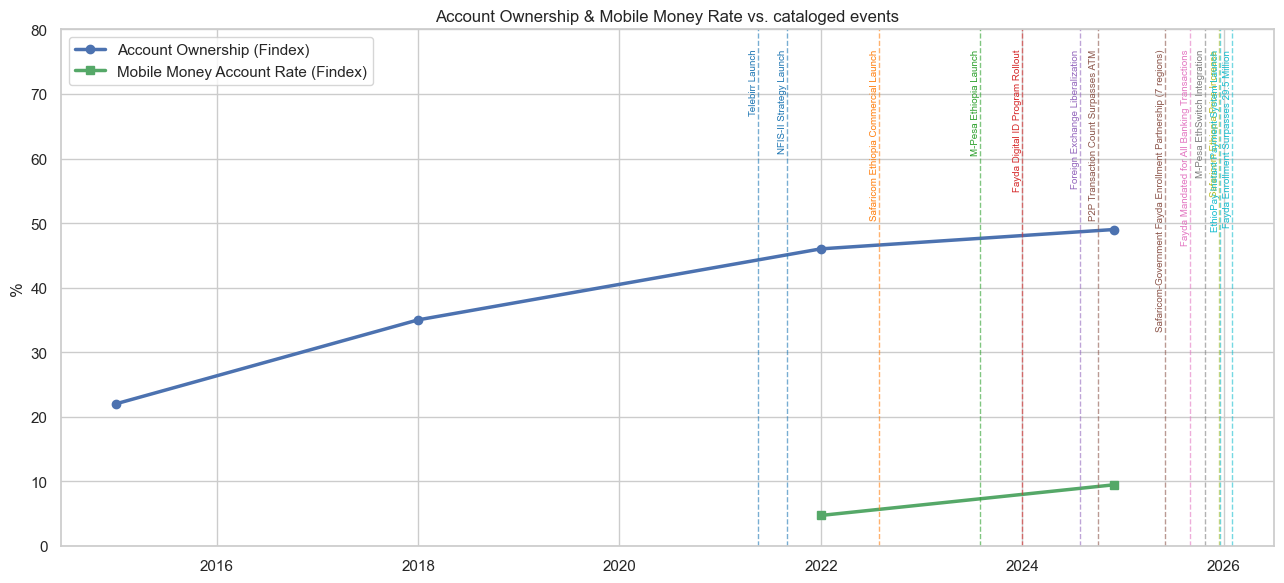

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(acc.observation_date, acc.value_numeric, marker="o", linewidth=2.5,
        color="#4C72B0", label="Account Ownership (Findex)")
ax.plot(mm.observation_date, mm.value_numeric, marker="s", linewidth=2.5,
        color="#55A868", label="Mobile Money Account Rate (Findex)")

ymin, ymax = 0, 80
colors_cycle = plt.cm.tab10(np.linspace(0, 1, len(events)))
for (_, ev), color in zip(events.sort_values("observation_date").iterrows(), colors_cycle):
    ax.axvline(ev.observation_date, color=color, linestyle="--", alpha=0.6, linewidth=1)
    ax.text(ev.observation_date, ymax - 3, ev.indicator, rotation=90, fontsize=7,
            va="top", ha="right", color=color)

ax.set_ylim(ymin, ymax)
ax.set_title("Account Ownership & Mobile Money Rate vs. cataloged events")
ax.set_ylabel("%")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_event_timeline_overlay.png", dpi=150)
plt.show()

**Visual read:** Telebirr (May 2021) sits right before the 2021 Findex round
that recorded 46% ownership / 4.7% mobile money — too early to show a
post-launch effect in that survey wave, but clearly precedes the 4.7%→9.45%
mobile money doubling by 2024. M-Pesa's entry (Aug 2023) and Safaricom's market
entry (Aug 2022) both fall inside the 2021→2024 inter-survey window, consistent
with mobile-money growth outpacing overall account-ownership growth in that
same window — supporting the "additive usage, not new inclusion" hypothesis.

## 11. Event → indicator relationships (impact_link summary)

In [11]:
event_impacts = events_with_impacts(df)
print(f"{len(event_impacts)} impact_links across {event_impacts.event_id.nunique()} events")
event_impacts[["event_name", "pillar", "related_indicator", "impact_direction",
               "impact_magnitude", "evidence_basis"]].sort_values("event_name")

25 impact_links across 13 events


,event_name,pillar,related_indicator,impact_direction,impact_magnitude,evidence_basis
17,EthioPay Instant Payment System Launch,ACCESS,ACC_OWNERSHIP,increase,medium,literature
16,EthioPay Instant Payment System Launch,USAGE,USG_P2P_COUNT,increase,high,literature
10,Fayda Digital ID Program Rollout,ACCESS,ACC_FAYDA,increase,high,empirical
9,Fayda Digital ID Program Rollout,ACCESS,ACC_OWNERSHIP,increase,medium,literature
24,Fayda Enrollment Surpasses 29.5 Million,TRUST,ACC_FAYDA,increase,low,expert
22,Fayda Mandated for All Banking Transactions,ACCESS,ACC_OWNERSHIP,mixed,medium,theoretical
11,Foreign Exchange Liberalization,AFFORDABILITY,AFF_DATA_INCOME,increase,medium,expert
12,Foreign Exchange Liberalization,ACCESS,ACC_OWNERSHIP,mixed,low,theoretical
14,M-Pesa EthSwitch Integration,USAGE,USG_MPESA_ACTIVE,increase,medium,literature
15,M-Pesa EthSwitch Integration,ACCESS,ACC_MM_ACCOUNT,increase,low,literature


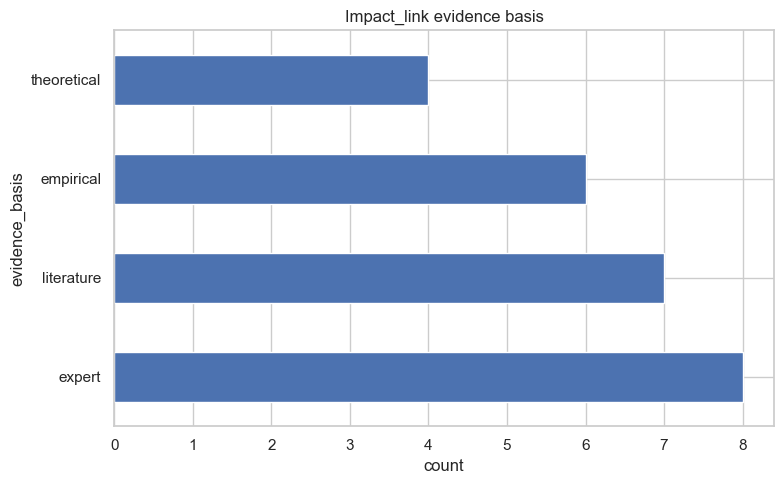

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
event_impacts.evidence_basis.value_counts().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Impact_link evidence basis")
ax.set_xlabel("count")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_evidence_basis.png", dpi=150)
plt.show()

Roughly a third of our reconstructed impact_links are `empirical` (grounded in
actual Ethiopian before/after data), with the rest split across `literature`
(comparable-country evidence), `theoretical`, and `expert` judgment — reflecting
real uncertainty about causal attribution that Task 3/4 must carry forward
honestly rather than treat as point estimates.

## 12. Correlation analysis

With only 4-5 points per indicator, formal correlation is fragile — but a
common-year join across the annually-reported "supply-side" indicators
(4G coverage, Fayda enrollment, mobile money account rate) is directionally
informative.

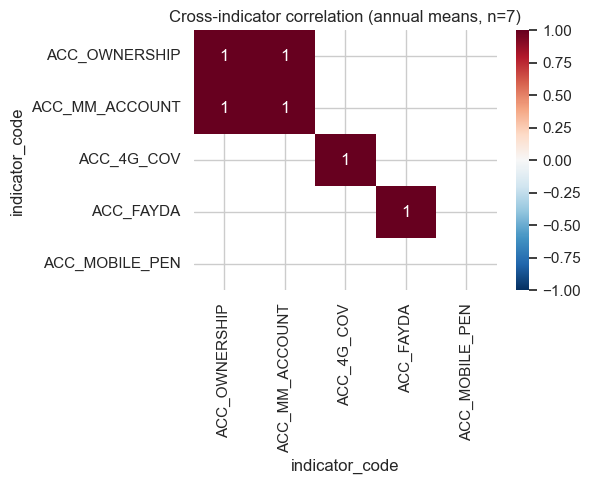

Caveat: n is very small (annual observations only back to 2021-2023 for most series) — treat these correlations as suggestive, not confirmatory.


In [13]:
pivot = obs_years.pivot_table(index="year", columns="indicator_code",
                               values="value_numeric", aggfunc="mean")
key_cols = [c for c in ["ACC_OWNERSHIP", "ACC_MM_ACCOUNT", "ACC_4G_COV",
                          "ACC_FAYDA", "ACC_MOBILE_PEN"] if c in pivot.columns]
corr = pivot[key_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Cross-indicator correlation (annual means, n={})".format(len(pivot)))
plt.tight_layout()
plt.savefig(FIG_DIR / "11_correlation_matrix.png", dpi=150)
plt.show()

print("Caveat: n is very small (annual observations only back to 2021-2023 for "
      "most series) — treat these correlations as suggestive, not confirmatory.")

## Key insights summary

1. **Account ownership growth decelerated sharply** (+13pp → +11pp → +3pp across
   the three most recent Findex periods) even as mobile money accounts doubled
   (4.7%→9.45%) and Telebirr/M-Pesa combined exceed 65M registered users —
   mobile money growth in Ethiopia is mostly *additive usage by the already-banked*,
   not new first-time inclusion (Market Nuance D: mobile-money-only users ~0.5%).
2. **The registered-vs-active gap is large and systemic**: only 66% of M-Pesa's
   registered users are 90-day active, and only ~20% of mobile money agents are
   weekly-active (averaging <1 transaction/day) — headline registration numbers
   substantially overstate functional usage.
3. **Digital payments have overtaken cash for the first time** (P2P/ATM ratio
   1.08 in FY2024/25, +158% YoY P2P growth vs. +26% ATM growth) — a genuine usage
   inflection point, distinct from the stalled access metric.
4. **The gender gap narrowed modestly** (20pp→15pp, 2021-2024) but women's share
   of mobile money accounts specifically is only 14%, far from the 2030 parity
   target — access gains have not yet been matched by mobile-money usage gains
   for women.
5. **Infrastructure expansion (4G coverage 37.5%→70.8%) is a plausible leading
   indicator** for usage-side growth, while physical branch/ATM density stayed
   low and flat — consistent with digital rails, not physical branch access,
   being the binding constraint on Usage (though not obviously on Access).
6. **Data is genuinely sparse**: most indicators have 1-4 observations across
   the whole window; only ACC_OWNERSHIP and ACC_FAYDA exceed that. Any
   correlation or regression work in Tasks 3-4 must carry wide uncertainty
   bands rather than imply false precision.

## Data quality assessment & limitations

- **Confidence mix:** starter data is predominantly `high` confidence (primary
  Findex/operator/regulator sources); our enrichment additions skew toward
  `medium`/`low` since several rely on secondary press synthesis of Findex 2025
  or NBE figures rather than the primary release.
- **No verified rural-specific 2024 account-ownership figure** — we deliberately
  avoided fabricating one via residual calculation (see data_enrichment_log.md §5).
- **Digital payment adoption figures are ambiguous across sources**: the 35%
  "made or received a digital payment" composite (REC_0034) sits well above
  some narrower activity-specific shares reported elsewhere (6% in-store, 7%
  bill pay, 1% online purchase) — these measure different things, but the gap
  is wide enough to flag as a real data-quality caveat.
- **The entire impact_link sheet (25 records) is our own reconstruction**, not
  sourced starter data — every impact estimate should be read as a documented
  hypothesis (with an honest evidence_basis label), not a verified fact.
- **Event dates for 2 of the 13 events (EVT_0011, EVT_0012) are approximate**,
  sourced from press coverage rather than confirmed regulatory effective dates.